# Data Science Intern Assignment - Primetrade.ai

### Import Libraries

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Part A — Data Preparation

In [198]:
# Loading both datasets
sentiment_df = pd.read_csv("../data/fear_greed_index.csv")
trader_df = pd.read_csv("../data/historical_data.csv")

print("Sentiment Dataset Shape:", sentiment_df.shape)
print("Trader Dataset Shape:", trader_df.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [199]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [200]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [201]:
print("Sentiment Columns:")
print(sentiment_df.columns)

print("\nTrader Columns:")
print(trader_df.columns)

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trader Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [202]:
print("Missing Values in Sentiment Dataset:")
display(sentiment_df.isnull().sum())

print("Missing Values in Trader Dataset:")
display(trader_df.isnull().sum())

Missing Values in Sentiment Dataset:


timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values in Trader Dataset:


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [203]:
print("Duplicate Rows in Sentiment Dataset:", sentiment_df.duplicated().sum())
print("Duplicate Rows in Trader Dataset:", trader_df.duplicated().sum())

Duplicate Rows in Sentiment Dataset: 0
Duplicate Rows in Trader Dataset: 0


### Convert Date and Timestamp Columns

In [204]:
# Convert sentiment date column
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

# Convert trader timestamp column
trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"], dayfirst=True, errors="coerce")

# Extract date from timestamp
trader_df["date"] = trader_df["Timestamp IST"].dt.date

In [205]:
print("Sentiment Date Range:")
print(sentiment_df["date"].min(), "to", sentiment_df["date"].max())

print("\nTrader Date Range:")
print(trader_df["date"].min(), "to", trader_df["date"].max())

Sentiment Date Range:
2018-02-01 to 2025-05-02

Trader Date Range:
2023-05-01 to 2025-05-01


### Merge Trader Data with Market Sentiment

In [206]:
merged_df = trader_df.merge(sentiment_df[["date", "classification"]], on="date", how="left")

print("Merged Dataset Shape:", merged_df.shape)
merged_df.head()

Merged Dataset Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [207]:
missing_sentiment = merged_df["classification"].isnull().sum()
print("Rows with Missing Sentiment After Merge:", missing_sentiment)

Rows with Missing Sentiment After Merge: 6


In [208]:
# Only 6 rows had missing sentiment after merging, which is very small compared to the full dataset. 
# These rows were removed to keep the analysis clean.

merged_df = merged_df.dropna(subset=["classification"])
print("Final Merged Dataset Shape:", merged_df.shape)

Final Merged Dataset Shape: (211218, 18)


### Convert Important Numeric Columns

In [209]:
numeric_columns = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee"
]

for col in numeric_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

### Create Basic Trade-Level Metrics

In [210]:
# A trade is considered winning if Closed PnL is greater than 0
merged_df["is_win"] = merged_df["Closed PnL"] > 0

# Trade value is already available as Size USD
merged_df["trade_value_usd"] = merged_df["Size USD"]

# Create a simple long/short direction column
merged_df["trade_direction"] = merged_df["Side"].map({
    "BUY": "Long/Buy",
    "SELL": "Short/Sell"
})

### Create Daily Trader-Level Metrics

In [211]:
daily_trader_metrics = merged_df.groupby(
    ["date", "Account", "classification"]
).agg(
    daily_pnl=("Closed PnL", "sum"),
    total_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    total_fees=("Fee", "sum")
).reset_index()

# Convert win rate into percentage
daily_trader_metrics["win_rate"] = daily_trader_metrics["win_rate"] * 100

daily_trader_metrics.head()

,date,Account,classification,daily_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,total_fees
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,0.000000,159.000000,477.00,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,9,0.000000,5556.203333,50005.83,12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,36.363636,10291.213636,113203.35,28.300831
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,0.000000,5304.975000,10609.95,2.652489
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,0.000000,5116.256667,15348.77,3.837189


### Create Sentiment-Level Summary Metrics

In [212]:
sentiment_summary = merged_df.groupby("classification").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    total_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    avg_fee=("Fee", "mean")
).reset_index()

sentiment_summary["win_rate"] = sentiment_summary["win_rate"] * 100

sentiment_summary

,classification,total_pnl,avg_pnl,median_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,avg_fee
0,Extreme Fear,7.391102e+05,34.537862,0.0,21400,37.060748,5349.731843,1.144843e+08,1.116291
1,Extreme Greed,2.715171e+06,67.892861,0.0,39992,46.494299,3112.251565,1.244652e+08,0.675902
2,Fear,3.357155e+06,54.290400,0.0,61837,42.076750,7816.109931,4.833248e+08,1.495172
3,Greed,2.150129e+06,42.743559,0.0,50303,38.482794,5736.884375,2.885825e+08,1.254372
4,Neutral,1.292921e+06,34.307718,0.0,37686,39.699093,4782.732661,1.802421e+08,1.044798


In [213]:
long_short_summary = merged_df.groupby(
    ["classification", "Side"]
).size().reset_index(name="trade_count")

long_short_summary

,classification,Side,trade_count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


In [214]:
trades_per_day = merged_df.groupby(
    ["date", "classification"]
).agg(
    total_trades=("Closed PnL", "count"),
    daily_pnl=("Closed PnL", "sum"),
    avg_trade_size_usd=("Size USD", "mean")
).reset_index()

trades_per_day.head()

,date,classification,total_trades,daily_pnl,avg_trade_size_usd
0,2023-05-01,Greed,3,0.000000,159.000000
1,2023-12-05,Extreme Greed,9,0.000000,5556.203333
2,2023-12-14,Greed,11,-205.434737,10291.213636
3,2023-12-15,Greed,2,-24.632034,5304.975000
4,2023-12-16,Greed,3,0.000000,5116.256667


In [215]:
trader_metrics = merged_df.groupby("Account").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    total_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    total_fees=("Fee", "sum")
).reset_index()

trader_metrics["win_rate"] = trader_metrics["win_rate"] * 100

trader_metrics.head()

,Account,total_pnl,avg_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,35.961236,16159.576734,61697263.97,7405.312304
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,44.271978,1653.226327,12035487.66,2729.837889
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,30.191651,8893.000898,33873440.42,9280.982850
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,43.858463,507.626933,6757022.10,2218.367366
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,51.991355,3138.894782,10166880.20,3108.196722


----------------------------

# PART B — Analysis

#### 1. Performance Summary by Market Sentiment

In [216]:
sentiment_summary = merged_df.groupby("classification").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    total_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    avg_fee=("Fee", "mean")
).reset_index()

sentiment_summary["win_rate"] = sentiment_summary["win_rate"] * 100

sentiment_summary

,classification,total_pnl,avg_pnl,median_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,avg_fee
0,Extreme Fear,7.391102e+05,34.537862,0.0,21400,37.060748,5349.731843,1.144843e+08,1.116291
1,Extreme Greed,2.715171e+06,67.892861,0.0,39992,46.494299,3112.251565,1.244652e+08,0.675902
2,Fear,3.357155e+06,54.290400,0.0,61837,42.076750,7816.109931,4.833248e+08,1.495172
3,Greed,2.150129e+06,42.743559,0.0,50303,38.482794,5736.884375,2.885825e+08,1.254372
4,Neutral,1.292921e+06,34.307718,0.0,37686,39.699093,4782.732661,1.802421e+08,1.044798


#### 2. Chart: Average PnL by Sentiment

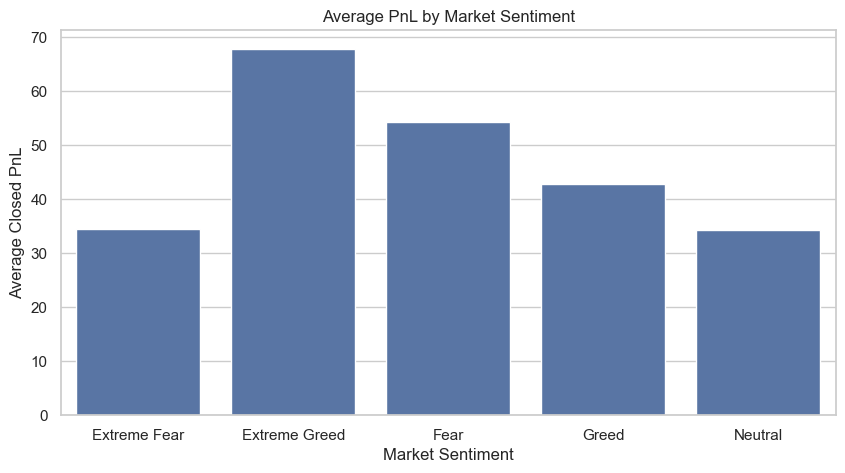

In [217]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_summary, x="classification", y="avg_pnl")

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.savefig("../charts/avg_pnl_by_sentiment.png")
plt.show()

#### 3. Chart: Win Rate by Sentiment

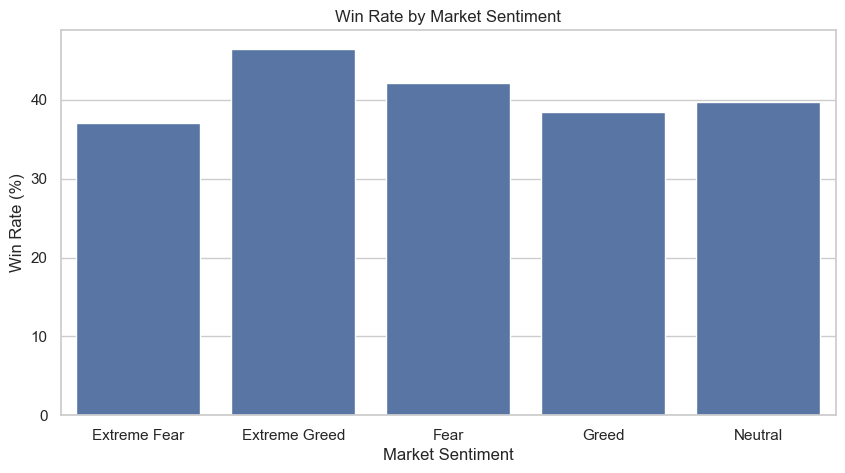

In [218]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_summary, x="classification", y="win_rate")

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.savefig("../charts/win_rate_by_sentiment.png")
plt.show()

#### 4. Trade Frequency by Sentiment

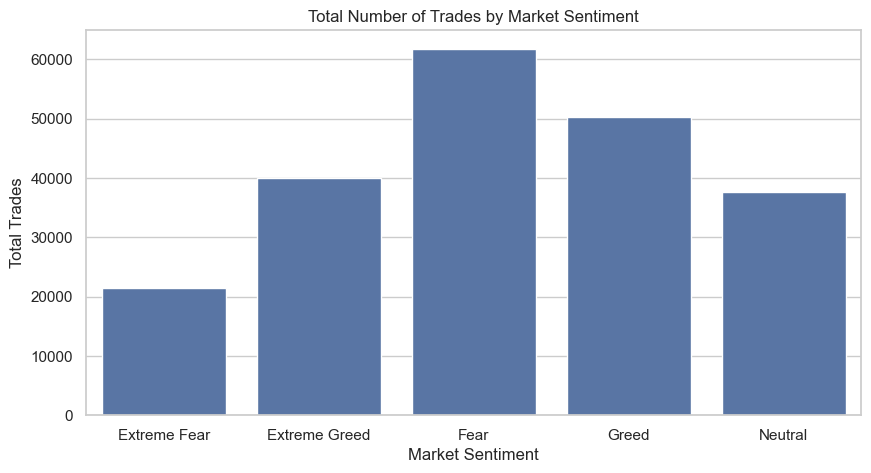

In [219]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_summary, x="classification", y="total_trades")

plt.title("Total Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Trades")
plt.savefig("../charts/trades_by_sentiment.png")
plt.show()

#### 5. Average Trade Size by Sentiment

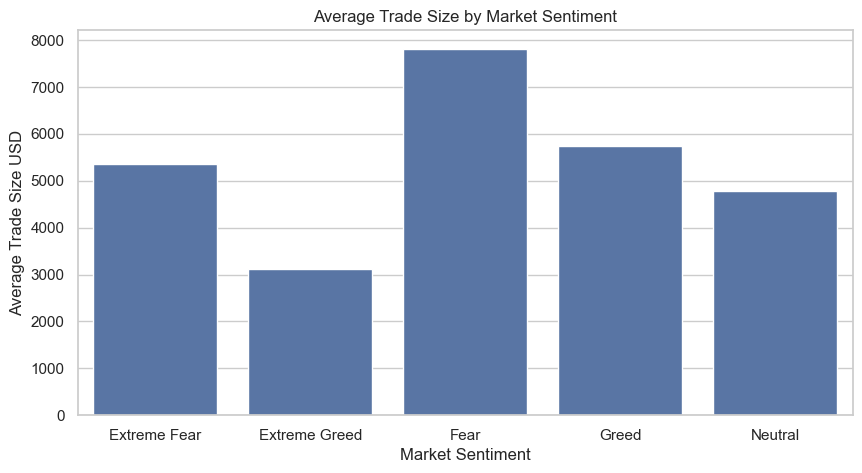

In [220]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_summary, x="classification", y="avg_trade_size_usd")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size USD")
plt.savefig("../charts/avg_trade_size_by_sentiment.png")
plt.show()

#### 6. Long/Short Behavior by Sentiment

In [221]:
long_short_summary = merged_df.groupby(
    ["classification", "Side"]
).size().reset_index(name="trade_count")

long_short_summary

,classification,Side,trade_count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


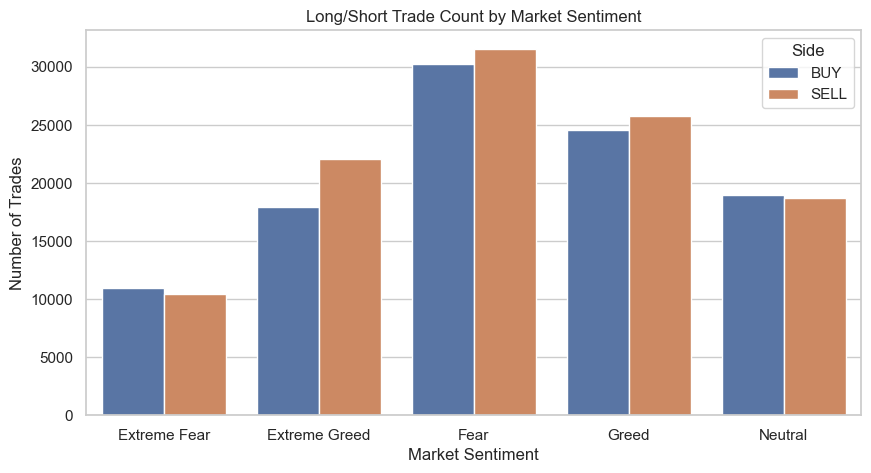

In [222]:
plt.figure(figsize=(10, 5))
sns.barplot(data=long_short_summary, x="classification", y="trade_count", hue="Side")

plt.title("Long/Short Trade Count by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("../charts/long_short_by_sentiment.png")
plt.show()

#### 7. Drawdown Proxy Analysis

In [223]:
daily_pnl = merged_df.groupby(["date", "classification"])["Closed PnL"].sum().reset_index()

daily_pnl = daily_pnl.sort_values("date")

daily_pnl["cumulative_pnl"] = daily_pnl["Closed PnL"].cumsum()
daily_pnl["running_max"] = daily_pnl["cumulative_pnl"].cummax()
daily_pnl["drawdown"] = daily_pnl["cumulative_pnl"] - daily_pnl["running_max"]

daily_pnl.head()

,date,classification,Closed PnL,cumulative_pnl,running_max,drawdown
0,2023-05-01,Greed,0.000000,0.000000,0.0,0.000000
1,2023-12-05,Extreme Greed,0.000000,0.000000,0.0,0.000000
2,2023-12-14,Greed,-205.434737,-205.434737,0.0,-205.434737
3,2023-12-15,Greed,-24.632034,-230.066771,0.0,-230.066771
4,2023-12-16,Greed,0.000000,-230.066771,0.0,-230.066771


In [224]:
drawdown_summary = daily_pnl.groupby("classification").agg(
    avg_daily_pnl=("Closed PnL", "mean"),
    worst_drawdown=("drawdown", "min")
).reset_index()

drawdown_summary

,classification,avg_daily_pnl,worst_drawdown
0,Extreme Fear,52793.589178,-135418.348004
1,Extreme Greed,23817.292199,-137369.608718
2,Fear,36891.818040,-135685.666052
3,Greed,11140.566181,-419020.225731
4,Neutral,19297.323516,-312613.843275


#### 8. Chart: Drawdown by Sentiment

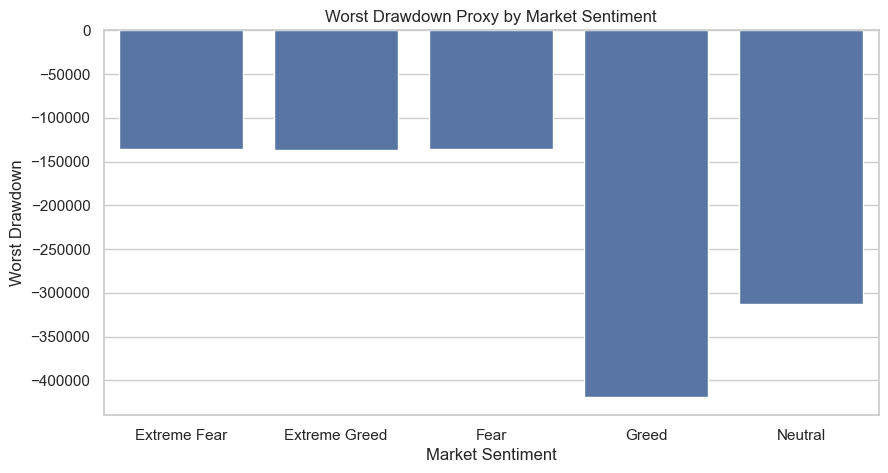

In [225]:
plt.figure(figsize=(10, 5))
sns.barplot(data=drawdown_summary, x="classification", y="worst_drawdown")

plt.title("Worst Drawdown Proxy by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Worst Drawdown")
plt.savefig("../charts/drawdown_by_sentiment.png")
plt.show()

### Trader Segmentation
#### 9. Create Trader-Level Metrics

In [226]:
trader_metrics = merged_df.groupby("Account").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    total_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
    total_fees=("Fee", "sum")
).reset_index()

trader_metrics["win_rate"] = trader_metrics["win_rate"] * 100

trader_metrics.head()

,Account,total_pnl,avg_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,3818,35.961236,16159.576734,61697263.97,7405.312304
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,7280,44.271978,1653.226327,12035487.66,2729.837889
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,3809,30.191651,8893.000898,33873440.42,9280.982850
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,13311,43.858463,507.626933,6757022.10,2218.367366
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,3239,51.991355,3138.894782,10166880.20,3108.196722


#### 10. Segment 1: Frequent vs Infrequent Traders

In [227]:
median_trades = trader_metrics["total_trades"].median()

trader_metrics["frequency_segment"] = np.where(
    trader_metrics["total_trades"] >= median_trades,
    "Frequent Trader",
    "Infrequent Trader"
)

frequency_segment_summary = trader_metrics.groupby("frequency_segment").agg(
    trader_count=("Account", "count"),
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades=("total_trades", "mean")
).reset_index()

frequency_segment_summary

,frequency_segment,trader_count,avg_total_pnl,avg_win_rate,avg_trades
0,Frequent Trader,16,496527.661215,41.356208,11684.8125
1,Infrequent Trader,16,144377.773117,39.238035,1516.3125


#### 11. Segment 2: Large Size vs Small Size Traders

In [228]:
median_trade_size = trader_metrics["avg_trade_size_usd"].median()

trader_metrics["size_segment"] = np.where(
    trader_metrics["avg_trade_size_usd"] >= median_trade_size,
    "Large Size Trader",
    "Small Size Trader"
)

size_segment_summary = trader_metrics.groupby("size_segment").agg(
    trader_count=("Account", "count"),
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size_usd=("avg_trade_size_usd", "mean")
).reset_index()

size_segment_summary

,size_segment,trader_count,avg_total_pnl,avg_win_rate,avg_trade_size_usd
0,Large Size Trader,16,416805.966542,36.168410,10151.775075
1,Small Size Trader,16,224099.467790,44.425833,1860.753834


#### 12. Segment 3: Consistent Winners vs Inconsistent Traders

In [229]:
trader_metrics["performance_segment"] = np.where(
    (trader_metrics["total_pnl"] > 0) & (trader_metrics["win_rate"] >= 50),
    "Consistent Winner",
    "Inconsistent Trader"
)

performance_segment_summary = trader_metrics.groupby("performance_segment").agg(
    trader_count=("Account", "count"),
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades=("total_trades", "mean")
).reset_index()

performance_segment_summary

,performance_segment,trader_count,avg_total_pnl,avg_win_rate,avg_trades
0,Consistent Winner,3,206866.631992,63.464381,4516.333333
1,Inconsistent Trader,29,332203.001839,37.900509,6816.172414


In [230]:
# Save Part B Output Tables

sentiment_summary.to_csv("../summary_tables/sentiment_summary.csv", index=False)
drawdown_summary.to_csv("../summary_tables/drawdown_summary.csv", index=False)
frequency_segment_summary.to_csv("../summary_tables/frequency_segment_summary.csv", index=False)
size_segment_summary.to_csv("../summary_tables/size_segment_summary.csv", index=False)
performance_segment_summary.to_csv("../summary_tables/performance_segment_summary.csv", index=False)

-------------

## BONUS — Trader Behavioral Clustering

In [231]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [232]:
clustering_df = trader_metrics.copy()

features = [
    "total_pnl",
    "total_trades",
    "win_rate",
    "avg_trade_size_usd",
    "total_volume_usd",
    "total_fees"
]

X = clustering_df[features].copy()
X.head()

,total_pnl,total_trades,win_rate,avg_trade_size_usd,total_volume_usd,total_fees
0,1.600230e+06,3818,35.961236,16159.576734,61697263.97,7405.312304
1,4.788532e+04,7280,44.271978,1653.226327,12035487.66,2729.837889
2,-7.043619e+04,3809,30.191651,8893.000898,33873440.42,9280.982850
3,1.324648e+05,13311,43.858463,507.626933,6757022.10,2218.367366
4,1.686580e+05,3239,51.991355,3138.894782,10166880.20,3108.196722


In [233]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [234]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0:5]

array([[ 2.6285848 , -0.34265657, -0.40570342,  1.41661703,  0.32265072,
        -0.01844025],
       [-0.55983695,  0.08366882,  0.3719224 , -0.60734741, -0.33202254,
        -0.32915941],
       [-0.80286219, -0.34376487, -0.94555634,  0.40276512, -0.0441407 ,
         0.10621164],
       [-0.38611579,  0.82635178,  0.3332303 , -0.76718448, -0.40160665,
        -0.36315033],
       [-0.31177716, -0.41395709,  1.09421498, -0.40006301, -0.35665572,
        -0.30401472]])

In [235]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_df["cluster"] = kmeans.fit_predict(X_scaled)

In [236]:
cluster_summary = clustering_df.groupby("cluster").agg(
    trader_count=("Account", "count"),
    avg_total_pnl=("total_pnl", "mean"),
    avg_trades=("total_trades", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size_usd=("avg_trade_size_usd", "mean"),
    avg_volume_usd=("total_volume_usd", "mean"),
    avg_fees=("total_fees", "mean")
).reset_index()

cluster_summary

,cluster,trader_count,avg_total_pnl,avg_trades,avg_win_rate,avg_trade_size_usd,avg_volume_usd,avg_fees
0,0,4,1.379964e+06,19981.750000,39.813973,6263.036707,6.509624e+07,11337.558983
1,1,25,1.425097e+05,4265.320000,40.409407,3725.960342,1.085151e+07,2188.267537
2,2,3,3.906290e+05,8219.333333,40.005604,24666.435723,2.198087e+08,48597.428003


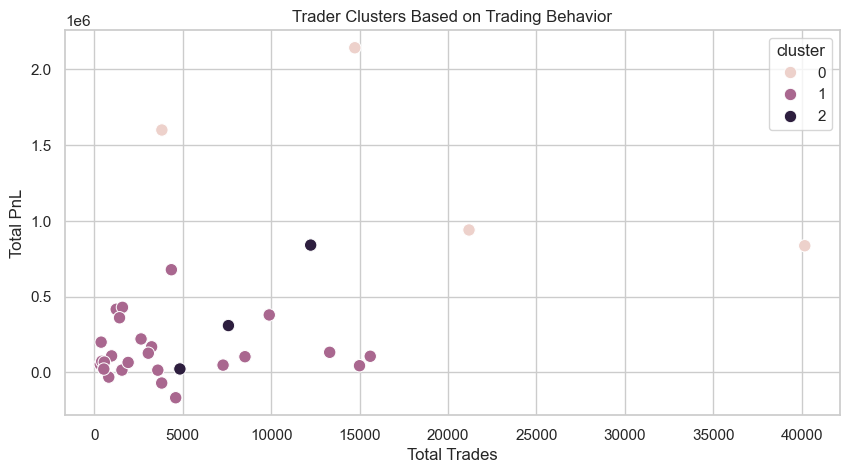

In [238]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=clustering_df, x="total_trades", y="total_pnl", hue="cluster", s=80)

plt.title("Trader Clusters Based on Trading Behavior")
plt.xlabel("Total Trades")
plt.ylabel("Total PnL")
plt.savefig("../charts/trader_clusters.png")
plt.show()

In [239]:
cluster_summary.to_csv("../summary_tables/cluster_summary.csv", index=False)
clustering_df.to_csv("../summary_tables/trader_clustered_data.csv", index=False)

## Part C — Actionable Output
Based on the analysis, two simple strategy ideas are suggested:

### Strategy 1: Reduce Position Size During Fear Days
Fear days had high trading activity and higher average trade size. This shows that traders were taking larger positions when the market was uncertain.

#### Rule of thumb: 
During Fear days, traders should reduce position size and avoid very large trades.

This is especially useful for large size traders and high activity traders because they already take higher exposure.

### Strategy 2: Avoid Overtrading During Greed Days

Greed days showed higher drawdown risk. This suggests that traders may become overconfident when market sentiment is positive.

#### Rule of thumb:
During Greed days, traders should avoid increasing trade frequency blindly and should keep risk limits fixed.

This is especially useful for frequent traders and high activity traders.

### Final Recommendation

Market sentiment should not be used as a direct buy or sell signal. It should be used as a risk management filter along with trader behavior metrics like trade frequency, win rate, position size, and drawdown.